# HGM-UNet3D Demonstration

This notebook presents a selected visualization example of three-dimensional bubble plume segmentation in multibeam water column data.

The notebook demonstrates:

1. loading an example input volume;
2. loading the corresponding manual annotation;
3. loading a previously saved HGM-UNet3D prediction;
4. inspecting the volumetric data;
5. comparing the manual annotation with the prediction;
6. displaying the corresponding three-dimensional visualization result.

> **Note:** This repository is intended for demonstration purposes. During manuscript review, only selected data samples and visualization procedures are provided. The complete model implementation, training pipeline, inference pipeline, model weights, and full datasets are not included.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk

from IPython.display import Image, display

print("Dependencies imported successfully.")

Dependencies imported successfully.


## 1. Load the demonstration data

The selected demonstration case consists of an input multibeam water column volume, its manual annotation, and a previously saved segmentation prediction.

In [3]:
repository_root = Path(".")

data_dir = repository_root / "sample_data"
image_dir = repository_root / "images"

volume_path = data_dir / "demo_volume.nii.gz"
ground_truth_path = data_dir / "demo_ground_truth.nii.gz"
prediction_path = data_dir / "demo_prediction.nii.gz"

result_figure_path ="demo_result.png"

print("Input volume:", volume_path)
print("Ground truth:", ground_truth_path)
print("Prediction:", prediction_path)

Input volume: sample_data\demo_volume.nii.gz
Ground truth: sample_data\demo_ground_truth.nii.gz
Prediction: sample_data\demo_prediction.nii.gz


In [4]:
required_files = {
    "Input volume": volume_path,
    "Ground truth": ground_truth_path,
    "Prediction": prediction_path,
}

missing_files = {
    name: path
    for name, path in required_files.items()
    if not path.exists()
}

if missing_files:
    print("The following files were not found:")
    for name, path in missing_files.items():
        print(f"- {name}: {path}")
else:
    print("All required demonstration files were found.")

All required demonstration files were found.


### Read the NIfTI volumes

SimpleITK is used to load the volumetric data. After conversion to NumPy arrays, the dimension order is `(Z, Y, X)`.

In [5]:
def load_nifti(path):
    image = sitk.ReadImage(str(path))
    array = sitk.GetArrayFromImage(image)
    return image, array


volume_image, volume = load_nifti(volume_path)
ground_truth_image, ground_truth = load_nifti(ground_truth_path)
prediction_image, prediction = load_nifti(prediction_path)

ground_truth = (ground_truth > 0).astype(np.uint8)
prediction = (prediction > 0).astype(np.uint8)

print("Volumes loaded successfully.")

Volumes loaded successfully.


In [6]:
print("Array order: (Z, Y, X)")
print()

print("Input shape:", volume.shape)
print("Ground-truth shape:", ground_truth.shape)
print("Prediction shape:", prediction.shape)

print()
print("Input dtype:", volume.dtype)
print("Ground-truth dtype:", ground_truth.dtype)
print("Prediction dtype:", prediction.dtype)

print()
print("Input value range:", float(volume.min()), "to", float(volume.max()))
print("Ground-truth values:", np.unique(ground_truth))
print("Prediction values:", np.unique(prediction))

print()
print("Voxel spacing (X, Y, Z):", volume_image.GetSpacing())

Array order: (Z, Y, X)

Input shape: (128, 1308, 2317)
Ground-truth shape: (128, 1308, 2317)
Prediction shape: (128, 1308, 2317)

Input dtype: uint8
Ground-truth dtype: uint8
Prediction dtype: uint8

Input value range: 0.0 to 255.0
Ground-truth values: [0 1]
Prediction values: [0 1]

Voxel spacing (X, Y, Z): (1.0, 1.0, 1.0)


In [7]:
if volume.ndim != 3:
    raise ValueError(
        f"The input volume must be three-dimensional, but got {volume.shape}."
    )

if ground_truth.shape != volume.shape:
    raise ValueError(
        f"Ground truth shape {ground_truth.shape} "
        f"does not match input shape {volume.shape}."
    )

if prediction.shape != volume.shape:
    raise ValueError(
        f"Prediction shape {prediction.shape} "
        f"does not match input shape {volume.shape}."
    )

print("The dimensions of all three volumes are consistent.")

The dimensions of all three volumes are consistent.


## 2. Select a representative slice

The representative slice is selected automatically according to the largest number of annotated plume voxels.

In [8]:
foreground_per_slice = ground_truth.sum(axis=(1, 2))

if foreground_per_slice.max() > 0:
    slice_index = int(np.argmax(foreground_per_slice))
else:
    slice_index = volume.shape[0] // 2

print("Selected slice index:", slice_index)
print(
    "Ground-truth plume voxels in this slice:",
    int(foreground_per_slice[slice_index]),
)

Selected slice index: 106
Ground-truth plume voxels in this slice: 44307


## 3. Qualitative comparison

The selected input slice, manual annotation, and saved HGM-UNet3D prediction are displayed side by side.

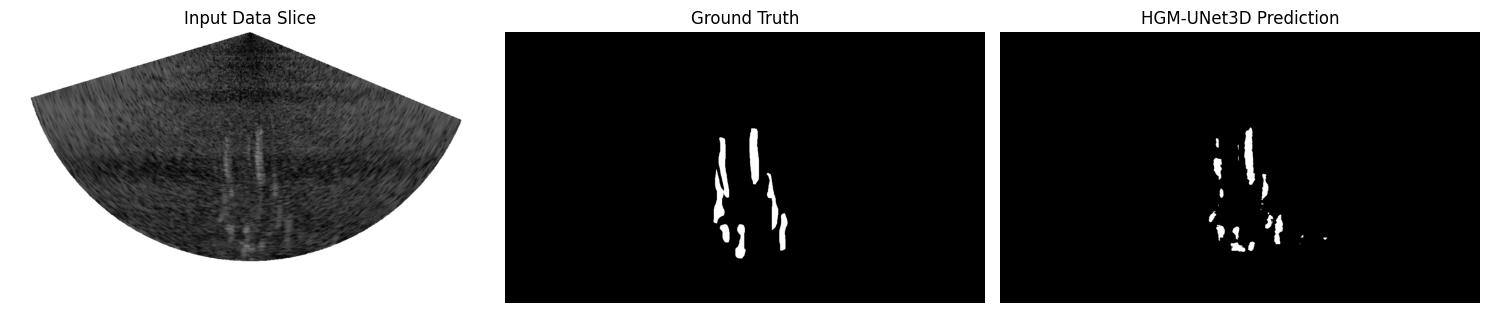

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(volume[slice_index], cmap="gray")
axes[0].set_title("Input Data Slice")
axes[0].axis("off")

axes[1].imshow(
    ground_truth[slice_index],
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(
    prediction[slice_index],
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[2].set_title("HGM-UNet3D Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 4. Segmentation overlays

The manual annotation and prediction are separately overlaid on the input slice for visual comparison.

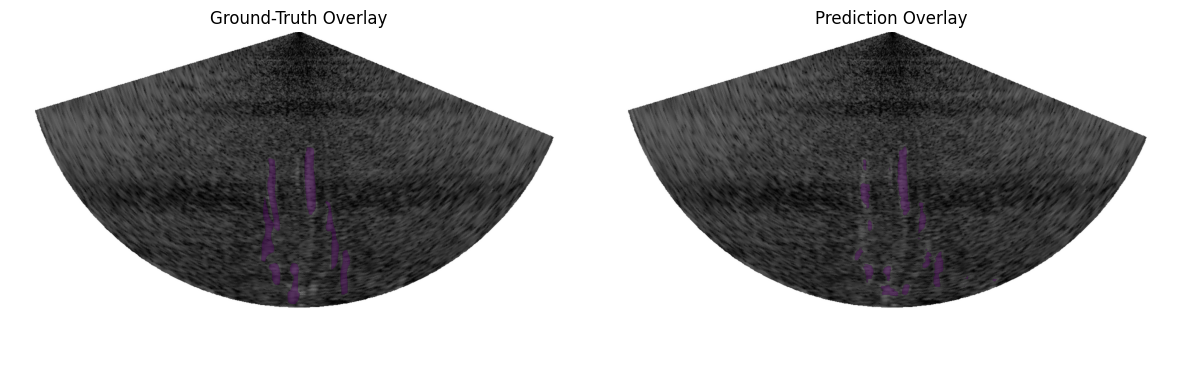

In [10]:
ground_truth_overlay = np.ma.masked_where(
    ground_truth[slice_index] == 0,
    ground_truth[slice_index],
)

prediction_overlay = np.ma.masked_where(
    prediction[slice_index] == 0,
    prediction[slice_index],
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(volume[slice_index], cmap="gray")
axes[0].imshow(ground_truth_overlay, alpha=0.5)
axes[0].set_title("Ground-Truth Overlay")
axes[0].axis("off")

axes[1].imshow(volume[slice_index], cmap="gray")
axes[1].imshow(prediction_overlay, alpha=0.5)
axes[1].set_title("Prediction Overlay")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 5. Consecutive slice visualization

Several neighboring slices are displayed to illustrate the spatial continuity of the plume structure.

In [11]:
number_of_slices = 5
half_window = number_of_slices // 2

start_index = max(0, slice_index - half_window)
end_index = min(
    volume.shape[0],
    slice_index + half_window + 1,
)

selected_indices = list(range(start_index, end_index))

print("Selected slice indices:", selected_indices)

Selected slice indices: [104, 105, 106, 107, 108]


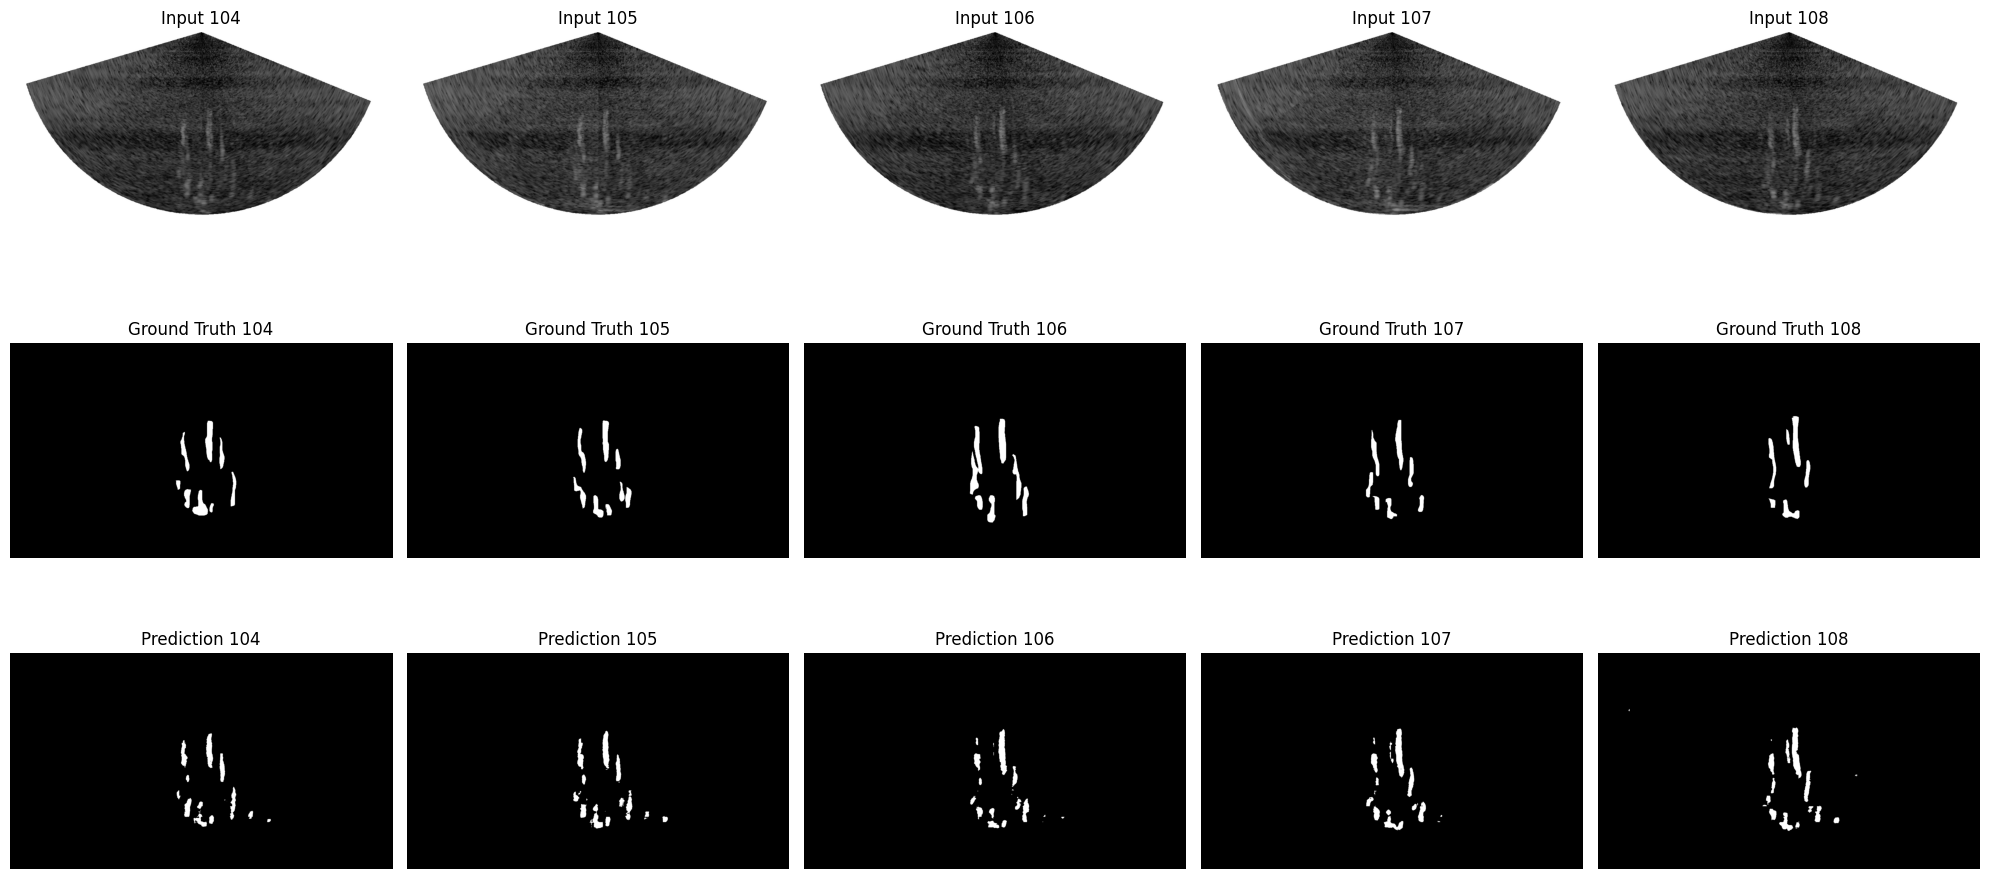

In [12]:
fig, axes = plt.subplots(
    3,
    len(selected_indices),
    figsize=(4 * len(selected_indices), 10),
    squeeze=False,
)

for column, index in enumerate(selected_indices):
    axes[0, column].imshow(volume[index], cmap="gray")
    axes[0, column].set_title(f"Input {index}")
    axes[0, column].axis("off")

    axes[1, column].imshow(
        ground_truth[index],
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[1, column].set_title(f"Ground Truth {index}")
    axes[1, column].axis("off")

    axes[2, column].imshow(
        prediction[index],
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[2, column].set_title(f"Prediction {index}")
    axes[2, column].axis("off")

plt.tight_layout()
plt.show()

## 6. Three-dimensional visualization

The following figure presents the selected volumetric example and its segmentation result. The three-dimensional rendering was generated using the established external visualization workflow.

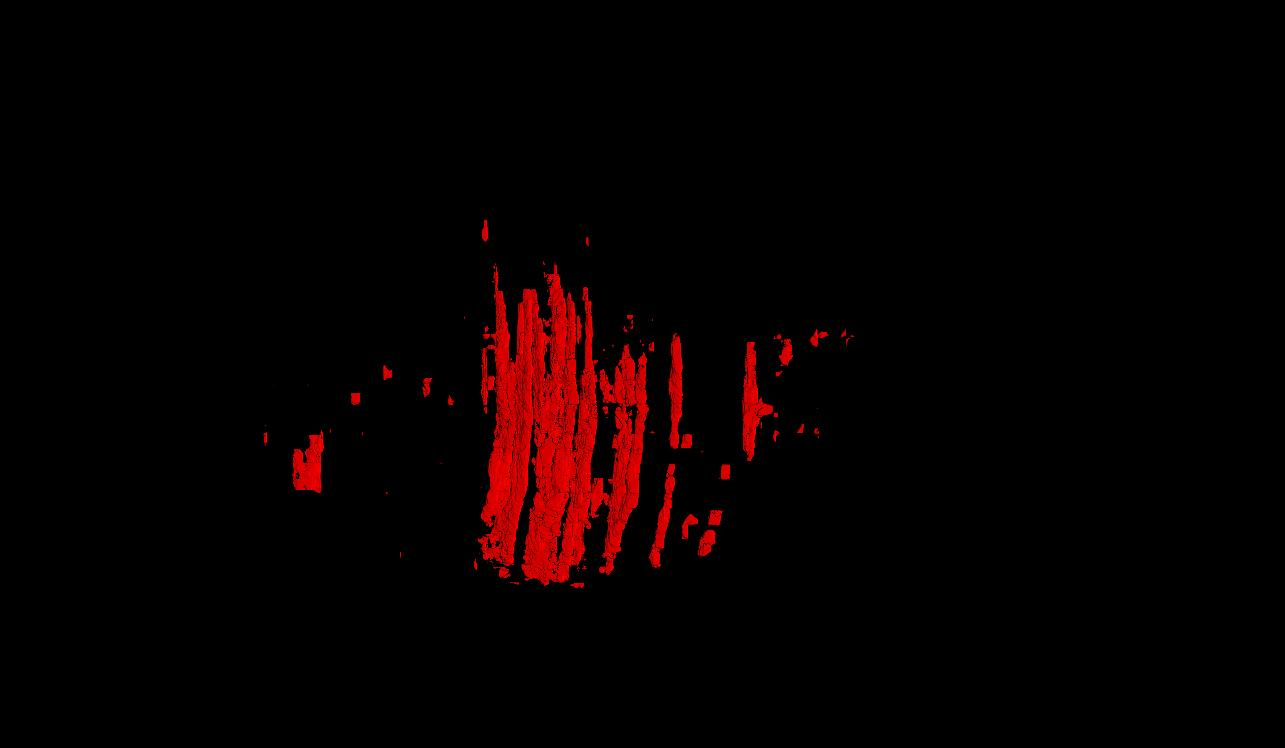

In [13]:
from pathlib import Path
from IPython.display import Image, display

result_figure_path = Path("demo_result.png")

if result_figure_path.exists():
    display(Image(filename=str(result_figure_path)))
else:
    print("3D visualization image not found.")

## Summary

This notebook demonstrates a selected HGM-UNet3D segmentation example through:

- NIfTI volume loading;
- volumetric data inspection;
- representative slice selection;
- ground-truth and prediction comparison;
- consecutive slice visualization;
- presentation of the corresponding three-dimensional result.

The complete model source code, training implementation, inference implementation, model weights, and full experimental datasets are not included during manuscript review.